# Extended Lab: Z-Scores, Z-Tests, and Statistical Power

This lab extends the four source notebooks (`3_1_Zscore_and_Zstatistics`, `3_2_Ztest_for_Means`,
`3_3_Ztest_for_Proportions`, `4_statistical_power`) with new datasets, visualizations, effect-size
and confidence-interval calculations, a Monte Carlo (simulation-based) power analysis, and a
full end-to-end A/B-testing capstone.

**How to use this notebook:** every section is fully worked — run it top to bottom to see how the
pieces connect. When you're ready to practice on your own, switch to `02_skeleton_practice.ipynb`,
which has the same structure with the code removed. Check your work against `05_solutions.ipynb`.

Read `00_theory_background.md` first (or alongside) if any formula below is unfamiliar.

**Contents**
- Part A — Z-scores refresher and visualization
- Part B — One-sample Z-test for a mean
- Part C — Two-sample Z-test for two means
- Part D — Z-tests for one and two proportions
- Part E — Confidence intervals (extension)
- Part F — Power analysis: t-test, z-test, chi-square, F-test/ANOVA
- Part G — Monte Carlo (simulation-based) power analysis for non-normal data
- Part H — Capstone: plan → simulate → test → report an A/B test


In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import math

from statsmodels.stats.weightstats import ztest
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.power import (
    TTestPower, TTestIndPower, NormalIndPower,
    GofChisquarePower, FTestPower, FTestAnovaPower
)
from statsmodels.stats.gof import chisquare_effectsize

np.random.seed(42)
plt.rcParams['figure.figsize'] = (7, 4)


## Part A — Z-scores refresher and visualization

**New scenario:** A university's Statistics 101 midterm is known (from years of history) to have
a population mean of 72 and a population standard deviation of 9. A section of 12 students just
took the exam. We'll standardize their scores, visualize where each student sits relative to the
class, and compute a couple of probability questions using the normal CDF — the same tools used
on the IQ example in `3_1`, applied to new numbers and with a picture added.

In [2]:
exam_scores = np.array([58, 65, 71, 74, 77, 80, 62, 90, 69, 85, 73, 55])
mu, sigma = 72, 9

z_scores = (exam_scores - mu) / sigma

exam_df = pd.DataFrame({"score": exam_scores, "z_score": z_scores}).sort_values("score").reset_index(drop=True)
exam_df

,score,z_score
0,55,-1.888889
1,58,-1.555556
2,62,-1.111111
3,65,-0.777778
4,69,-0.333333
5,71,-0.111111
6,73,0.111111
7,74,0.222222
8,77,0.555556
9,80,0.888889


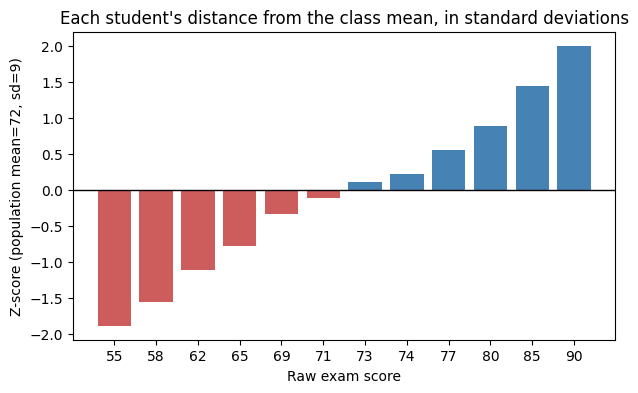

In [3]:
fig, ax = plt.subplots()
ax.bar(range(len(exam_df)), exam_df["z_score"],
       color=np.where(exam_df["z_score"] >= 0, "steelblue", "indianred"))
ax.axhline(0, color="black", linewidth=1)
ax.set_xticks(range(len(exam_df)))
ax.set_xticklabels(exam_df["score"])
ax.set_xlabel("Raw exam score")
ax.set_ylabel("Z-score (population mean=72, sd=9)")
ax.set_title("Each student's distance from the class mean, in standard deviations")
plt.show()

**Question:** what fraction of the population is expected to score between 65 and 85?

We standardize both endpoints and take the difference of their CDF values — exactly the pattern
used for the IQ example in `3_1`, just with a fresh pair of bounds.

In [4]:
z_low = (65 - mu) / sigma
z_high = (85 - mu) / sigma

prob_between = stats.norm.cdf(z_high) - stats.norm.cdf(z_low)
print(f"z(65) = {z_low:.3f}, z(85) = {z_high:.3f}")
print(f"P(65 < score < 85) = {prob_between:.4f} -> about {prob_between*100:.2f}% of students")

z(65) = -0.778, z(85) = 1.444
P(65 < score < 85) = 0.7073 -> about 70.73% of students


Visualizing the same probability as shaded area under the standard normal curve:

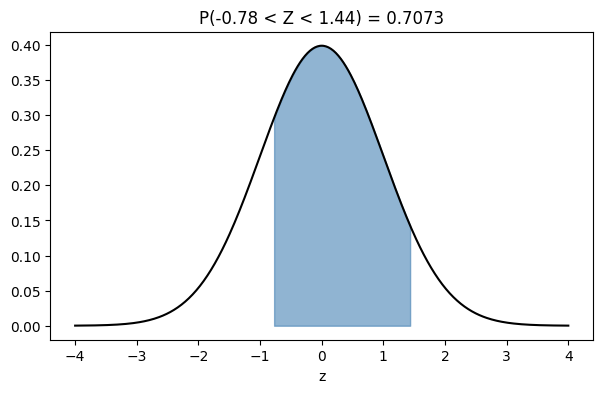

In [5]:
x = np.linspace(-4, 4, 400)
y = stats.norm.pdf(x)

fig, ax = plt.subplots()
ax.plot(x, y, color="black")
mask = (x >= z_low) & (x <= z_high)
ax.fill_between(x[mask], y[mask], color="steelblue", alpha=0.6)
ax.set_title(f"P({z_low:.2f} < Z < {z_high:.2f}) = {prob_between:.4f}")
ax.set_xlabel("z")
plt.show()

**Sampling distribution version:** what is the probability that the *mean* of a random sample of
6 students falls between 65 and 85? This uses the standard error (σ/√n) instead of σ, exactly the
distinction drawn between "a single score" and "a sample mean" in `3_1`.

In [6]:
n = 6
se = sigma / math.sqrt(n)

z_low_mean = (65 - mu) / se
z_high_mean = (85 - mu) / se

prob_mean_between = stats.norm.cdf(z_high_mean) - stats.norm.cdf(z_low_mean)
print(f"Standard error for n={n}: {se:.3f}")
print(f"P(65 < sample mean < 85) = {prob_mean_between:.4f} -> about {prob_mean_between*100:.2f}%")
print("Notice this probability is much higher than the single-score probability above -- ")
print("sample means vary less than individual observations.")

Standard error for n=6: 3.674
P(65 < sample mean < 85) = 0.9714 -> about 97.14%
Notice this probability is much higher than the single-score probability above -- 
sample means vary less than individual observations.


## Part B — One-sample Z-test for a mean

**New scenario:** A coffee shop chain claims its average drive-through wait time is 4.5 minutes
with a known population standard deviation of 1.2 minutes (from years of operational data). A
new store manager suspects wait times have gotten *longer* after a menu change. She times 40
random customers and finds a sample mean wait of 4.9 minutes.

- H₀: μ ≤ 4.5 (wait times have not increased)
- Hₐ: μ > 4.5 (wait times have increased) — a **right-tailed** test
- α = 0.05

We'll solve this three ways: manually with the z-formula, with the critical-value approach, and
with `statsmodels.ztest`, and show all three agree.

In [7]:
mu0 = 4.5     # hypothesized population mean
sigma_wait = 1.2
n_wait = 40
xbar_wait = 4.9
alpha = 0.05

z_stat = (xbar_wait - mu0) / (sigma_wait / math.sqrt(n_wait))
p_value = stats.norm.sf(z_stat)   # right-tailed: P(Z >= z_stat)

print(f"Test statistic z = {z_stat:.4f}")
print(f"p-value (right-tailed) = {p_value:.6f}")

crit_right = stats.norm.ppf(1 - alpha)
print(f"Critical value (right-tailed, alpha={alpha}) = {crit_right:.4f}")

if z_stat > crit_right:
    print("Decision: REJECT H0 -- wait times appear to have increased.")
else:
    print("Decision: fail to reject H0.")

Test statistic z = 2.1082
p-value (right-tailed) = 0.017507
Critical value (right-tailed, alpha=0.05) = 1.6449
Decision: REJECT H0 -- wait times appear to have increased.


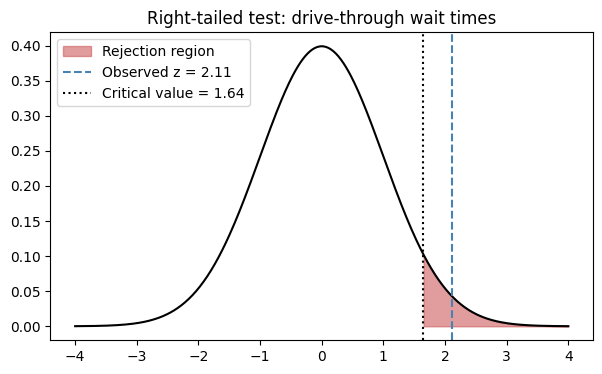

In [8]:
fig, ax = plt.subplots()
x = np.linspace(-4, 4, 400)
y = stats.norm.pdf(x)
ax.plot(x, y, color="black")
reject_region = x >= crit_right
ax.fill_between(x[reject_region], y[reject_region], color="indianred", alpha=0.6, label="Rejection region")
ax.axvline(z_stat, color="steelblue", linestyle="--", label=f"Observed z = {z_stat:.2f}")
ax.axvline(crit_right, color="black", linestyle=":", label=f"Critical value = {crit_right:.2f}")
ax.legend()
ax.set_title("Right-tailed test: drive-through wait times")
plt.show()

Since we don't have the raw 40 wait times (only their summary mean), we simulate a plausible sample consistent with that mean and known sigma, purely to demonstrate the `ztest()` helper function on raw data -- in a real analysis you would use your *actual* collected sample here, not a simulated stand-in.

In [9]:
simulated_waits = np.random.normal(loc=xbar_wait, scale=sigma_wait, size=n_wait)

z_stat_sm, p_value_sm = ztest(simulated_waits, value=mu0, alternative='larger')
print(f"statsmodels ztest -> z = {z_stat_sm:.4f}, p = {p_value_sm:.6f}")
print("(Small differences from the manual calculation above are expected: statsmodels uses the")
print(" *sample* standard deviation from the simulated data, and simulation introduces sampling noise.)")

statsmodels ztest -> z = 0.7613, p = 0.223229
(Small differences from the manual calculation above are expected: statsmodels uses the
 *sample* standard deviation from the simulated data, and simulation introduces sampling noise.)


## Part C — Two-sample Z-test for two means

**New scenario:** Two factories (X and Y) each produce the same widget. Management wants to know
whether the mean daily output differs between the two factories.

- H₀: μ_X − μ_Y = 0
- Hₐ: μ_X − μ_Y ≠ 0 (two-tailed)
- α = 0.05

In [10]:
factory_X = [412, 405, 398, 420, 415, 402, 411, 408, 419, 400,
             414, 407, 403, 417, 410, 406, 413, 409, 401, 416,
             404, 418, 399, 412, 411, 405, 408, 414, 402, 410]
factory_Y = [395, 388, 401, 392, 390, 397, 394, 385, 399, 391,
             396, 389, 393, 400, 387, 398, 392, 386, 395, 390,
             393, 391, 397, 388, 394, 399, 386, 392, 400, 389]

z_stat_xy, p_value_xy = ztest(factory_X, factory_Y, value=0, alternative='two-sided')
print(f"z = {z_stat_xy:.4f}, p-value = {p_value_xy:.6f}")

alpha = 0.05
if p_value_xy <= alpha:
    print("Decision: REJECT H0 -- the mean outputs differ between factories.")
else:
    print("Decision: fail to reject H0.")

z = 11.3750, p-value = 0.000000
Decision: REJECT H0 -- the mean outputs differ between factories.


**Effect size (Cohen's d)** — is the difference not just statistically significant, but practically large?

In [11]:
def pooled_standard_deviation(sample1, sample2):
    n1, n2 = len(sample1), len(sample2)
    s1, s2 = np.std(sample1, ddof=1), np.std(sample2, ddof=1)
    return math.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2))

pooled_sd = pooled_standard_deviation(factory_X, factory_Y)
cohens_d = abs(np.mean(factory_X) - np.mean(factory_Y)) / pooled_sd
print(f"Pooled SD = {pooled_sd:.3f}")
print(f"Cohen's d = {cohens_d:.3f}")
print("Rule of thumb: 0.2 small, 0.5 medium, 0.8 large -- this is a large effect.")

Pooled SD = 5.470
Cohen's d = 2.937
Rule of thumb: 0.2 small, 0.5 medium, 0.8 large -- this is a large effect.


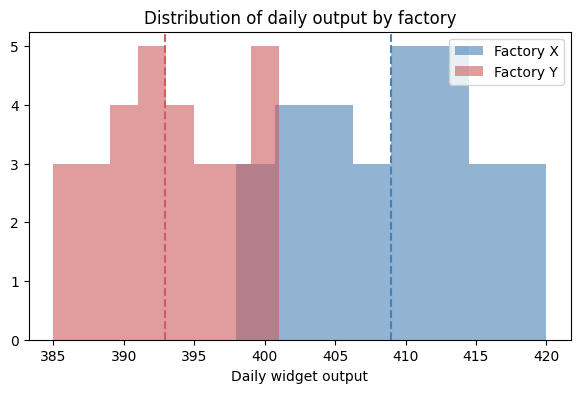

In [12]:
fig, ax = plt.subplots()
ax.hist(factory_X, bins=8, alpha=0.6, label="Factory X", color="steelblue")
ax.hist(factory_Y, bins=8, alpha=0.6, label="Factory Y", color="indianred")
ax.axvline(np.mean(factory_X), color="steelblue", linestyle="--")
ax.axvline(np.mean(factory_Y), color="indianred", linestyle="--")
ax.set_xlabel("Daily widget output")
ax.legend()
ax.set_title("Distribution of daily output by factory")
plt.show()

## Part D — Z-tests for one and two proportions

**New scenario (one-proportion):** A mobile game studio historically sees a 12% conversion rate
from free trial to paid subscription. After a UI redesign, a sample of 800 new trial users shows
110 conversions. Has the conversion rate changed?

- H₀: p = 0.12
- Hₐ: p ≠ 0.12 (two-tailed)

In [13]:
count_conversions = 110
nobs_trials = 800
p0 = 0.12

z_stat_p, p_value_p = proportions_ztest(count_conversions, nobs_trials, p0, alternative='two-sided')
observed_p = count_conversions / nobs_trials
print(f"Observed proportion = {observed_p:.4f}")
print(f"z = {z_stat_p:.4f}, p-value = {p_value_p:.6f}")

alpha = 0.05
print("REJECT H0" if p_value_p <= alpha else "Fail to reject H0")

Observed proportion = 0.1375
z = 1.4373, p-value = 0.150628
Fail to reject H0


**New scenario (two-proportion):** The studio also wants to know whether the redesign performs
differently on iOS vs. Android. iOS: 92 conversions out of 620 trials. Android: 78 conversions out
of 590 trials.

In [14]:
p1_bar = 92 / 620
p2_bar = 78 / 590
n1, n2 = 620, 590

p_pool = (p1_bar * n1 + p2_bar * n2) / (n1 + n2)
z_stat_2p = (p1_bar - p2_bar) / math.sqrt(p_pool * (1 - p_pool) * (1/n1 + 1/n2))
p_value_2p = stats.norm.sf(abs(z_stat_2p)) * 2

print(f"iOS conversion rate: {p1_bar:.4f}, Android conversion rate: {p2_bar:.4f}")
print(f"Pooled proportion: {p_pool:.4f}")
print(f"z = {z_stat_2p:.4f}, p-value = {p_value_2p:.6f}")

alpha = 0.05
print("REJECT H0 -- platforms differ" if p_value_2p <= alpha else "Fail to reject H0 -- no evidence platforms differ")

iOS conversion rate: 0.1484, Android conversion rate: 0.1322
Pooled proportion: 0.1405
z = 0.8098, p-value = 0.418083
Fail to reject H0 -- no evidence platforms differ


In [15]:
# Cross-check with the statsmodels helper (same numbers, ready-made function)
z_check, p_check = proportions_ztest([92, 78], [620, 590], alternative='two-sided')
print(f"statsmodels cross-check -> z = {z_check:.4f}, p = {p_check:.6f}")

statsmodels cross-check -> z = 0.8098, p = 0.418083


## Part E — Confidence intervals (extension)

The source notebooks stop at hypothesis tests. A confidence interval answers a complementary
question: not just "is the parameter equal to this value?" but "what's a plausible *range* for the
true parameter?" For a z-based CI on a mean:

  x̄ ± z_(α/2) · (σ/√n)

and for a proportion:

  p̂ ± z_(α/2) · √(p̂(1−p̂)/n)

In [16]:
def z_confidence_interval_mean(xbar, sigma, n, confidence=0.95):
    alpha = 1 - confidence
    z_crit = stats.norm.ppf(1 - alpha/2)
    margin = z_crit * (sigma / math.sqrt(n))
    return xbar - margin, xbar + margin

ci_wait = z_confidence_interval_mean(xbar_wait, sigma_wait, n_wait, confidence=0.95)
print(f"95% CI for true mean wait time: ({ci_wait[0]:.3f}, {ci_wait[1]:.3f}) minutes")

def z_confidence_interval_proportion(p_hat, n, confidence=0.95):
    alpha = 1 - confidence
    z_crit = stats.norm.ppf(1 - alpha/2)
    margin = z_crit * math.sqrt(p_hat * (1 - p_hat) / n)
    return p_hat - margin, p_hat + margin

ci_conversion = z_confidence_interval_proportion(observed_p, nobs_trials, confidence=0.95)
print(f"95% CI for true conversion rate: ({ci_conversion[0]:.4f}, {ci_conversion[1]:.4f})")

95% CI for true mean wait time: (4.528, 5.272) minutes
95% CI for true conversion rate: (0.1136, 0.1614)


Note the direct link between hypothesis testing and confidence intervals: a two-sided test at level α rejects H0: parameter = value exactly when that value falls *outside* the (1-α) confidence interval. Check that 0.12 falls outside the conversion-rate interval above, consistent with rejecting H0 in Part D.

## Part F — Power analysis: t-test, z-test, chi-square, F-test/ANOVA

This section mirrors `4_statistical_power.ipynb` with fresh numbers, and adds power-curve plots
so you can *see* the power/sample-size/effect-size relationship, not just read a single number.

### F.1 — One-sample t-test power (unknown population sigma)

A quality engineer wants to detect whether a new process shifts mean output from 500 units to 520 units, with an estimated standard deviation of 45 units, at α=0.05.

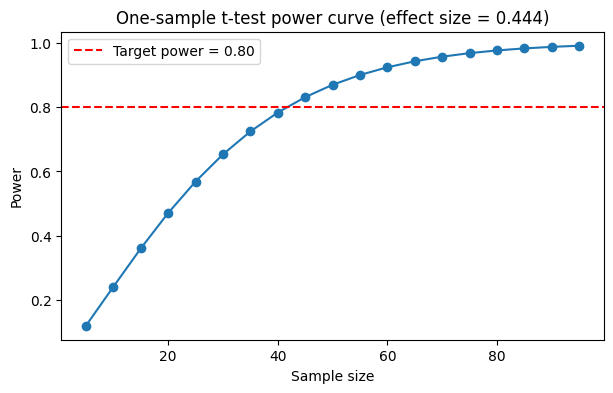

Approximate sample size needed for 80% power: 42


In [17]:
effect_size_t = abs(520 - 500) / 45
alpha = 0.05

powers_t = TTestPower()
sample_sizes = np.arange(5, 100, 5)
power_values = [powers_t.solve_power(effect_size_t, nobs=n, alpha=alpha, alternative='two-sided')
                for n in sample_sizes]

fig, ax = plt.subplots()
ax.plot(sample_sizes, power_values, marker='o')
ax.axhline(0.8, color='red', linestyle='--', label='Target power = 0.80')
ax.set_xlabel('Sample size')
ax.set_ylabel('Power')
ax.set_title(f'One-sample t-test power curve (effect size = {effect_size_t:.3f})')
ax.legend()
plt.show()

required_n = powers_t.solve_power(effect_size_t, power=0.8, alpha=alpha, alternative='two-sided')
print(f"Approximate sample size needed for 80% power: {math.ceil(required_n)}")

### F.2 — Two-sample (pooled) z-test power for a mean difference

Reusing the two-factory scenario from Part C: if the *true* Cohen's d is what we observed, how much power did our n=30-per-group design actually have?

In [18]:
powers_z = NormalIndPower()
achieved_power = powers_z.solve_power(cohens_d, nobs1=30, ratio=1.0, alpha=0.05, alternative='two-sided')
print(f"Achieved power with n=30 per group and d={cohens_d:.3f}: {achieved_power:.4f}")

# And the reverse question: how many samples would we need for 90% power?
required_n_z = powers_z.solve_power(cohens_d, power=0.9, ratio=1.0, alpha=0.05, alternative='two-sided')
print(f"Sample size per group needed for 90% power: {math.ceil(required_n_z)}")

Achieved power with n=30 per group and d=2.937: 1.0000
Sample size per group needed for 90% power: 3


### F.3 — Chi-square goodness-of-fit power

A streaming service expects viewers to be evenly split across 3 genres (33.3% each). A survey of preferences instead suggests 25% / 45% / 30%. Was the survey (n=150) big enough to reliably detect a difference this size, at α=0.05, power target 0.8?

In [19]:
effect_size_chi = chisquare_effectsize(probs0=[1/3, 1/3, 1/3], probs1=[0.25, 0.45, 0.30], cohen=True)
print(f"Cohen's w effect size: {effect_size_chi:.4f}")

power_chi = GofChisquarePower()
achieved_power_chi = power_chi.solve_power(effect_size_chi, nobs=150, alpha=0.05, n_bins=3)
print(f"Achieved power with n=150: {achieved_power_chi:.4f}")

required_n_chi = power_chi.solve_power(effect_size_chi, power=0.8, alpha=0.05, n_bins=3)
print(f"Sample size needed for 80% power: {math.ceil(required_n_chi)}")

Cohen's w effect size: 0.2550
Achieved power with n=150: 0.8050
Sample size needed for 80% power: 149


### F.4 — F-test / ANOVA power across more than two groups

Extending the ANOVA example from `4_statistical_power`: three delivery routes with different mean delivery times. How many deliveries per route are needed to detect a difference, given estimated per-route standard deviations?

In [20]:
route_stats = pd.DataFrame({
    "route": ["A", "B", "C"],
    "mean": [38, 41, 36],
    "std": [5.0, 5.5, 4.8],
    "n": [40, 35, 45],
})
route_stats

,route,mean,std,n
0,A,38,5.0,40
1,B,41,5.5,35
2,C,36,4.8,45


In [21]:
def pooled_sd_multi(df):
    numerator = sum((row['n'] - 1) * row['std']**2 for _, row in df.iterrows())
    denominator = sum(row['n'] - 1 for _, row in df.iterrows())
    return math.sqrt(numerator / denominator)

pooled_sd_routes = pooled_sd_multi(route_stats)
effect_size_anova = (route_stats['mean'].max() - route_stats['mean'].min()) / pooled_sd_routes
print(f"Pooled SD across routes: {pooled_sd_routes:.3f}")
print(f"Effect size (Cohen's f approximation used here): {effect_size_anova:.3f}")

power_anova = FTestAnovaPower()
required_n_anova = power_anova.solve_power(effect_size=effect_size_anova, nobs=None,
                                            alpha=0.05, power=0.8, k_groups=3)
print(f"Sample size needed PER ROUTE for 80% power: {math.ceil(required_n_anova)}")

Pooled SD across routes: 5.078
Effect size (Cohen's f approximation used here): 0.985
Sample size needed PER ROUTE for 80% power: 14


## Part G — Monte Carlo (simulation-based) power analysis for non-normal data

The first markdown cell in `4_statistical_power.ipynb` flags an important limitation: **the
closed-form power formulas above assume normally distributed data.** When your data is heavily
skewed, has heavy tails, or is bounded (like counts or ratios), the textbook formula's power
number can be unreliable. The standard workaround is **simulation**: repeatedly generate fake
datasets under a specified "true" (possibly non-normal) distribution, run the actual test on each
one, and see what fraction of simulations correctly reject H0. That empirical rejection rate *is*
the power, no normality assumption required — the price is computation time instead of a
closed-form formula.

In [22]:
def monte_carlo_power_two_sample_t(n_per_group, true_diff, distribution='normal',
                                    alpha=0.05, n_simulations=2000, seed=0):
    """
    Empirically estimate power for a two-sample independent t-test by simulation.
    distribution: 'normal' or 'exponential' (right-skewed, to show a non-normal case)
    true_diff: the true difference in group means baked into the simulation
    """
    rng = np.random.default_rng(seed)
    rejections = 0

    for _ in range(n_simulations):
        if distribution == 'normal':
            group1 = rng.normal(loc=0, scale=1, size=n_per_group)
            group2 = rng.normal(loc=true_diff, scale=1, size=n_per_group)
        elif distribution == 'exponential':
            # exponential is right-skewed and non-normal; shift group2's mean by true_diff
            group1 = rng.exponential(scale=1, size=n_per_group)
            group2 = rng.exponential(scale=1, size=n_per_group) + true_diff
        else:
            raise ValueError("distribution must be 'normal' or 'exponential'")

        t_stat, p_val = stats.ttest_ind(group1, group2)
        if p_val <= alpha:
            rejections += 1

    return rejections / n_simulations

power_normal = monte_carlo_power_two_sample_t(n_per_group=30, true_diff=0.6, distribution='normal')
power_skewed = monte_carlo_power_two_sample_t(n_per_group=30, true_diff=0.6, distribution='exponential')

print(f"Simulated power (normal data, n=30/group, true diff=0.6): {power_normal:.3f}")
print(f"Simulated power (right-skewed data, n=30/group, true diff=0.6): {power_skewed:.3f}")
print()
print("Compare to the closed-form formula's power for the same effect size:")
closed_form_power = TTestIndPower().solve_power(effect_size=0.6, nobs1=30, ratio=1.0, alpha=0.05)
print(f"Closed-form (normal-theory) power estimate: {closed_form_power:.3f}")

Simulated power (normal data, n=30/group, true diff=0.6): 0.617
Simulated power (right-skewed data, n=30/group, true diff=0.6): 0.649

Compare to the closed-form formula's power for the same effect size:
Closed-form (normal-theory) power estimate: 0.628


Run the cell above a few times or change `true_diff` / `n_per_group` and watch how the skewed-data power estimate can diverge from the normal-theory formula -- this is the concrete version of the limitation flagged in the theory document.

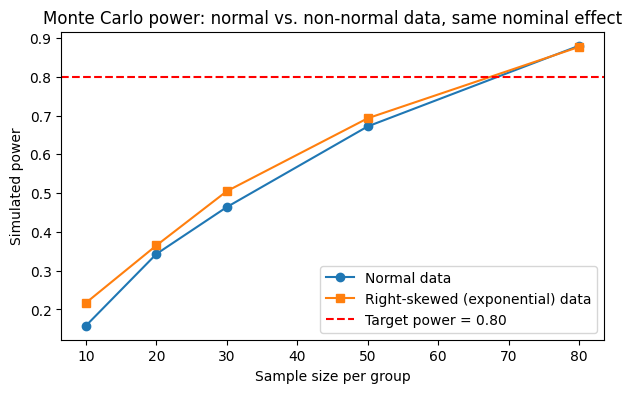

In [23]:
sample_sizes_mc = [10, 20, 30, 50, 80]
powers_normal_curve = [monte_carlo_power_two_sample_t(n, 0.5, 'normal', n_simulations=1000) for n in sample_sizes_mc]
powers_skewed_curve = [monte_carlo_power_two_sample_t(n, 0.5, 'exponential', n_simulations=1000) for n in sample_sizes_mc]

fig, ax = plt.subplots()
ax.plot(sample_sizes_mc, powers_normal_curve, marker='o', label='Normal data')
ax.plot(sample_sizes_mc, powers_skewed_curve, marker='s', label='Right-skewed (exponential) data')
ax.axhline(0.8, color='red', linestyle='--', label='Target power = 0.80')
ax.set_xlabel('Sample size per group')
ax.set_ylabel('Simulated power')
ax.set_title('Monte Carlo power: normal vs. non-normal data, same nominal effect')
ax.legend()
plt.show()

## Part H — Capstone: plan → simulate → test → report an A/B test

This section walks the *entire* workflow end to end, the way you would on a real project:

1. **Plan**: decide the minimum effect size worth detecting, and use power analysis to determine
   the required sample size before collecting any data.
2. **Simulate data collection** (standing in for an actual experiment).
3. **Test**: run the appropriate hypothesis test.
4. **Report**: state the conclusion, the effect size, a confidence interval, and the scope of
   inference — exactly the four hypothesis-test steps from the theory document.

**Scenario:** An e-commerce site wants to test a new checkout button color. Baseline conversion
rate is 8%. The team considers a 2-percentage-point lift (to 10%) the smallest improvement worth
shipping the change for.

In [24]:
# --- Step 1: Plan sample size ---
p_baseline = 0.08
p_target = 0.10
alpha = 0.05
desired_power = 0.8

# statsmodels has a dedicated proportion effect size helper
from statsmodels.stats.power import zt_ind_solve_power
from statsmodels.stats.proportion import proportion_effectsize

effect_size_ab = proportion_effectsize(p_target, p_baseline)
required_n_ab = NormalIndPower().solve_power(effect_size_ab, power=desired_power, ratio=1.0,
                                              alpha=alpha, alternative='two-sided')
required_n_ab = math.ceil(required_n_ab)
print(f"Effect size (h): {effect_size_ab:.4f}")
print(f"Required sample size PER GROUP for {desired_power*100:.0f}% power: {required_n_ab}")

Effect size (h): 0.0700
Required sample size PER GROUP for 80% power: 3205


In [25]:
# --- Step 2: Simulate data collection ---
# Stand-in for a real experiment: randomly assign visitors and simulate conversions
# using the TRUE rates we hypothesized above (this is only possible in a simulation --
# in a real study you would not know the true rates in advance).
rng = np.random.default_rng(7)

n_control = required_n_ab
n_treatment = required_n_ab

conversions_control = rng.binomial(n=1, p=p_baseline, size=n_control).sum()
conversions_treatment = rng.binomial(n=1, p=p_target, size=n_treatment).sum()

print(f"Control:   {conversions_control} conversions out of {n_control} "
      f"({conversions_control/n_control:.4f})")
print(f"Treatment: {conversions_treatment} conversions out of {n_treatment} "
      f"({conversions_treatment/n_treatment:.4f})")

Control:   248 conversions out of 3205 (0.0774)
Treatment: 321 conversions out of 3205 (0.1002)


In [26]:
# --- Step 3: Test ---
z_stat_ab, p_value_ab = proportions_ztest(
    [conversions_treatment, conversions_control],
    [n_treatment, n_control],
    alternative='two-sided'
)
print(f"z = {z_stat_ab:.4f}, p-value = {p_value_ab:.6f}")
decision = "REJECT H0 -- conversion rates differ" if p_value_ab <= alpha else "Fail to reject H0"
print(f"Decision at alpha={alpha}: {decision}")

z = 3.2059, p-value = 0.001346
Decision at alpha=0.05: REJECT H0 -- conversion rates differ


In [27]:
# --- Step 4: Report ---
p_hat_control = conversions_control / n_control
p_hat_treatment = conversions_treatment / n_treatment
observed_lift = p_hat_treatment - p_hat_control

p_pool_ab = (conversions_control + conversions_treatment) / (n_control + n_treatment)
se_diff = math.sqrt(p_pool_ab * (1 - p_pool_ab) * (1/n_control + 1/n_treatment))
z_crit_95 = stats.norm.ppf(0.975)
ci_low = observed_lift - z_crit_95 * se_diff
ci_high = observed_lift + z_crit_95 * se_diff

print("=== A/B Test Report ===")
print(f"H0: p_treatment - p_control = 0   |   Ha: p_treatment - p_control != 0")
print(f"Sample size per group: {required_n_ab} (planned via power analysis for 80% power)")
print(f"Observed control rate:   {p_hat_control:.4f}")
print(f"Observed treatment rate: {p_hat_treatment:.4f}")
print(f"Observed lift: {observed_lift:.4f} (95% CI: [{ci_low:.4f}, {ci_high:.4f}])")
print(f"Test statistic z = {z_stat_ab:.4f}, p-value = {p_value_ab:.6f}")
print(f"Conclusion: {decision}")
print()
print("Scope of inference: this conclusion applies to visitors from the same population and time")
print("period as the sample -- it does not automatically generalize to a different season, traffic")
print("source, or user segment without further evidence.")

=== A/B Test Report ===
H0: p_treatment - p_control = 0   |   Ha: p_treatment - p_control != 0
Sample size per group: 3205 (planned via power analysis for 80% power)
Observed control rate:   0.0774
Observed treatment rate: 0.1002
Observed lift: 0.0228 (95% CI: [0.0089, 0.0367])
Test statistic z = 3.2059, p-value = 0.001346
Conclusion: REJECT H0 -- conversion rates differ

Scope of inference: this conclusion applies to visitors from the same population and time
period as the sample -- it does not automatically generalize to a different season, traffic
source, or user segment without further evidence.


## Wrap-up

You've now practiced every method from the four source notebooks plus several natural extensions:
visualizing rejection regions and z-distributions, computing effect sizes and confidence intervals,
running power analyses across four different test families, empirically checking power under a
non-normal distribution via simulation, and running a full plan-to-report A/B test workflow.

**Next steps:**
- Try `02_skeleton_practice.ipynb` to redo similar exercises from scratch without the answers.
- Use `03_cheat_sheet.ipynb` as a quick reference while you work.
- Adapt `04_reusable_template.ipynb` for your own dataset or project.
- Compare your skeleton attempt against `05_solutions.ipynb` when you're done.
